In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('used_cars.csv')
df.head()

,brand,model,model_year,milage,fuel_type,engine,transmission,ext_col,int_col,accident,clean_title,price
0,Ford,Utility Police Interceptor Base,2013,"51,000 mi.",E85 Flex Fuel,300.0HP 3.7L V6 Cylinder Engine Flex Fuel Capa...,6-Speed A/T,Black,Black,At least 1 accident or damage reported,Yes,"$10,300"
1,Hyundai,Palisade SEL,2021,"34,742 mi.",Gasoline,3.8L V6 24V GDI DOHC,8-Speed Automatic,Moonlight Cloud,Gray,At least 1 accident or damage reported,Yes,"$38,005"
2,Lexus,RX 350 RX 350,2022,"22,372 mi.",Gasoline,3.5 Liter DOHC,Automatic,Blue,Black,None reported,NaN,"$54,598"
3,INFINITI,Q50 Hybrid Sport,2015,"88,900 mi.",Hybrid,354.0HP 3.5L V6 Cylinder Engine Gas/Electric H...,7-Speed A/T,Black,Black,None reported,Yes,"$15,500"
4,Audi,Q3 45 S line Premium Plus,2021,"9,835 mi.",Gasoline,2.0L I4 16V GDI DOHC Turbo,8-Speed Automatic,Glacier White Metallic,Black,None reported,NaN,"$34,999"


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4009 entries, 0 to 4008
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   brand         4009 non-null   str  
 1   model         4009 non-null   str  
 2   model_year    4009 non-null   int64
 3   milage        4009 non-null   str  
 4   fuel_type     3839 non-null   str  
 5   engine        4009 non-null   str  
 6   transmission  4009 non-null   str  
 7   ext_col       4009 non-null   str  
 8   int_col       4009 non-null   str  
 9   accident      3896 non-null   str  
 10  clean_title   3413 non-null   str  
 11  price         4009 non-null   str  
dtypes: int64(1), str(11)
memory usage: 892.6 KB


In [4]:
df.describe()

,model_year
count,4009.000000
mean,2015.515590
std,6.104816
min,1974.000000
25%,2012.000000
50%,2017.000000
75%,2020.000000
max,2024.000000


In [5]:
df.shape

(4009, 12)

In [6]:
df.duplicated().sum()

np.int64(0)

In [7]:
df.isnull().sum()

brand             0
model             0
model_year        0
milage            0
fuel_type       170
engine            0
transmission      0
ext_col           0
int_col           0
accident        113
clean_title     596
price             0
dtype: int64

In [8]:
df['price'] = df['price'].str.replace('$', '', regex=False).str.replace(',', '', regex=False).astype(int)

In [9]:
df['milage'] = df['milage'].str.replace('mi.', '', regex=False).str.replace(',', '', regex=False).str.strip().astype(int)

In [10]:
df[['price', 'milage']].describe()

,price,milage
count,4.009000e+03,4009.000000
mean,4.455319e+04,64717.551010
std,7.871064e+04,52296.599459
min,2.000000e+03,100.000000
25%,1.720000e+04,23044.000000
50%,3.100000e+04,52775.000000
75%,4.999000e+04,94100.000000
max,2.954083e+06,405000.000000


In [11]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4009 entries, 0 to 4008
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   brand         4009 non-null   str  
 1   model         4009 non-null   str  
 2   model_year    4009 non-null   int64
 3   milage        4009 non-null   int64
 4   fuel_type     3839 non-null   str  
 5   engine        4009 non-null   str  
 6   transmission  4009 non-null   str  
 7   ext_col       4009 non-null   str  
 8   int_col       4009 non-null   str  
 9   accident      3896 non-null   str  
 10  clean_title   3413 non-null   str  
 11  price         4009 non-null   int64
dtypes: int64(3), str(9)
memory usage: 825.9 KB


In [12]:
df['fuel_type'].unique()

<ArrowStringArray>
[ 'E85 Flex Fuel',       'Gasoline',         'Hybrid',              nan,
         'Diesel', 'Plug-In Hybrid',              '–',  'not supported']
Length: 8, dtype: str

In [13]:
df['fuel_type'] = df['fuel_type'].replace(['–', 'not supported'], pd.NA)

In [14]:
df['fuel_type'].unique()

<ArrowStringArray>
['E85 Flex Fuel', 'Gasoline', 'Hybrid', nan, 'Diesel', 'Plug-In Hybrid']
Length: 6, dtype: str

In [15]:
df['fuel_type'].value_counts(dropna=False)

fuel_type
Gasoline          3309
NaN                217
Hybrid             194
E85 Flex Fuel      139
Diesel             116
Plug-In Hybrid      34
Name: count, dtype: int64

In [16]:
text_cols = df.select_dtypes(include='object').columns
for col in text_cols:
    print(col, '-', df[col].str.strip().eq(df[col]).all())

brand - True
model - True
fuel_type - False
engine - True
transmission - True
ext_col - True
int_col - True
accident - False
clean_title - False


/var/folders/_s/l9md4_2x5rj1z5hmcz54bvnr0000gn/T/ipykernel_1865/1567688263.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  text_cols = df.select_dtypes(include='object').columns


In [17]:
text_cols = df.select_dtypes(include='str').columns
for col in text_cols:
    mask = df[col].notna()
    clean = df.loc[mask, col].str.strip().eq(df.loc[mask, col]).all()
    print(col, '-', clean)

brand - True
model - True
fuel_type - True
engine - True
transmission - True
ext_col - True
int_col - True
accident - True
clean_title - True


In [18]:
df['clean_title'] = df['clean_title'].fillna('No')

In [19]:
df['accident'] = df['accident'].fillna('Unknown')

In [20]:
df['fuel_type'] = df['fuel_type'].fillna('Unknown')

In [21]:
df.isnull().sum()

brand           0
model           0
model_year      0
milage          0
fuel_type       0
engine          0
transmission    0
ext_col         0
int_col         0
accident        0
clean_title     0
price           0
dtype: int64

In [22]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4009 entries, 0 to 4008
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   brand         4009 non-null   str  
 1   model         4009 non-null   str  
 2   model_year    4009 non-null   int64
 3   milage        4009 non-null   int64
 4   fuel_type     4009 non-null   str  
 5   engine        4009 non-null   str  
 6   transmission  4009 non-null   str  
 7   ext_col       4009 non-null   str  
 8   int_col       4009 non-null   str  
 9   accident      4009 non-null   str  
 10  clean_title   4009 non-null   str  
 11  price         4009 non-null   int64
dtypes: int64(3), str(9)
memory usage: 827.7 KB


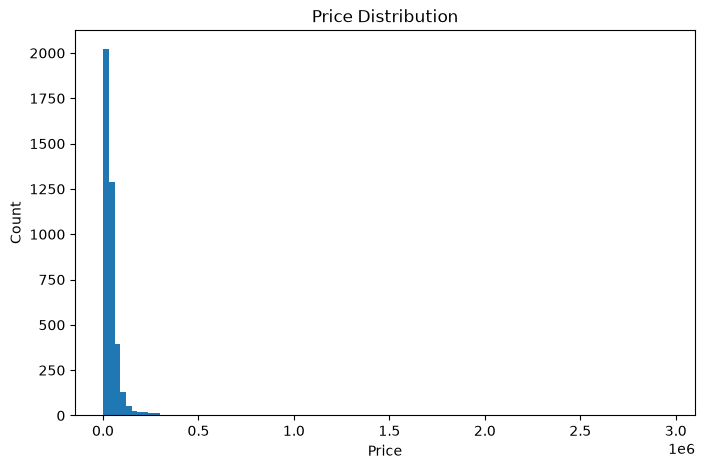

In [23]:
plt.figure(figsize=(8,5))
plt.hist(df['price'], bins=100)
plt.xlabel('Price')
plt.ylabel('Count')
plt.title('Price Distribution')
plt.show()

In [24]:
df.sort_values('price', ascending=False).head(15)

,brand,model,model_year,milage,fuel_type,engine,transmission,ext_col,int_col,accident,clean_title,price
693,Maserati,Quattroporte Base,2005,32000,Gasoline,394.0HP 4.2L 8 Cylinder Engine Gasoline Fuel,Transmission w/Dual Shift Mode,Red,Beige,At least 1 accident or damage reported,Yes,2954083
229,Bugatti,Veyron 16.4 Grand Sport,2011,6330,Gasoline,8.0L W16 64V GDI DOHC Twin Turbo,7-Speed Automatic with Auto-Shift,White,White,None reported,Yes,1950995
3046,Porsche,Carrera GT Base,2005,4400,Gasoline,605.0HP 5.7L 10 Cylinder Engine Gasoline Fuel,6-Speed M/T,Gray,Black,None reported,Yes,1599000
1356,Lamborghini,Aventador SVJ Base,2021,6987,Gasoline,6.5L V12 48V MPFI DOHC,7-Speed,–,Nero Ade,None reported,Yes,749950
624,Rolls-Royce,Cullinan,2022,398,Gasoline,6.7L V12 48V GDI DOHC Twin Turbo,8-Speed Automatic,Silver,Charles Blue,None reported,Yes,695000
979,Lamborghini,Aventador SVJ Base,2019,6929,Gasoline,759.0HP 6.5L 12 Cylinder Engine Gasoline Fuel,A/T,Blue,Black,None reported,Yes,649999
1615,Rolls-Royce,Phantom,2023,1560,Unknown,–,–,Tempest,Cobalt Blue,None reported,Yes,599995
1508,Rolls-Royce,Phantom,2018,7585,Gasoline,6.8L V12 48V GDI DOHC Twin Turbo,8-Speed Automatic,–,–,None reported,Yes,599000
3655,Lamborghini,Aventador S Base,2018,5858,Gasoline,729.0HP 6.5L 12 Cylinder Engine Gasoline Fuel,7-Speed A/T,White,Gray,None reported,Yes,491836
1061,Dodge,Viper GTC,2017,1389,Gasoline,645.0HP 8.4L 10 Cylinder Engine Gasoline Fuel,M/T,Black,Black,None reported,Yes,489995


In [25]:
df['price'].quantile([0.90, 0.95, 0.99, 0.999])

0.900     79999.000
0.950    111600.000
0.990    272713.280
0.999    694639.992
Name: price, dtype: float64

In [26]:
df = df[df['price'] != 2954083]
df['price'].describe()

count    4.008000e+03
mean     4.382726e+04
std      6.390414e+04
min      2.000000e+03
25%      1.717500e+04
50%      3.100000e+04
75%      4.996000e+04
max      1.950995e+06
Name: price, dtype: float64

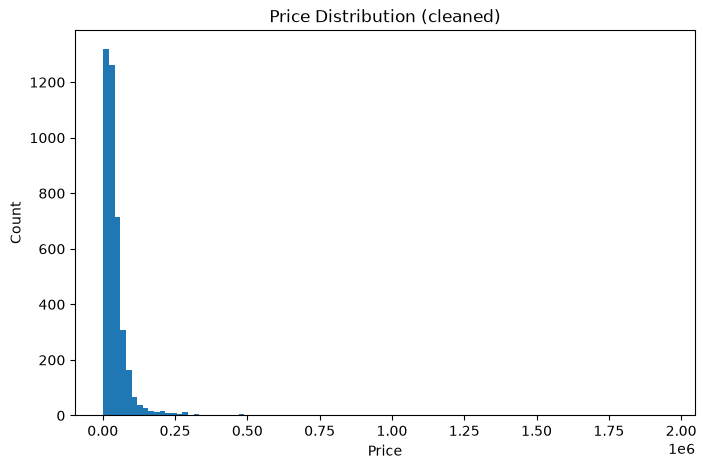

In [27]:
plt.figure(figsize=(8,5))
plt.hist(df['price'], bins=100)
plt.xlabel('Price')
plt.ylabel('Count')
plt.title('Price Distribution (cleaned)')
plt.show()

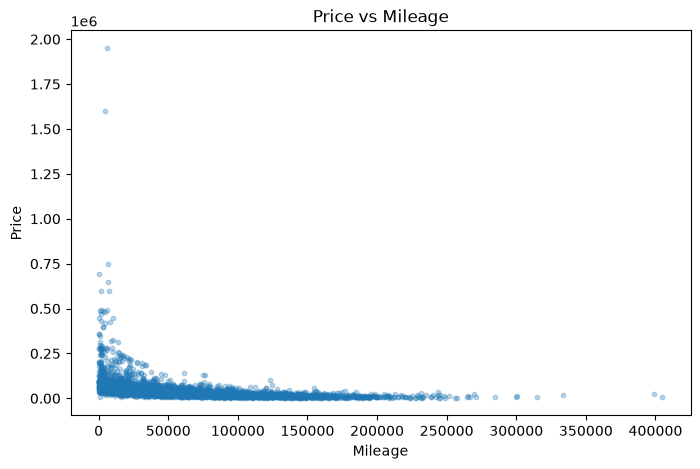

In [28]:
plt.figure(figsize=(8,5))
plt.scatter(df['milage'], df['price'], alpha=0.3, s=10)
plt.xlabel('Mileage')
plt.ylabel('Price')
plt.title('Price vs Mileage')
plt.show()

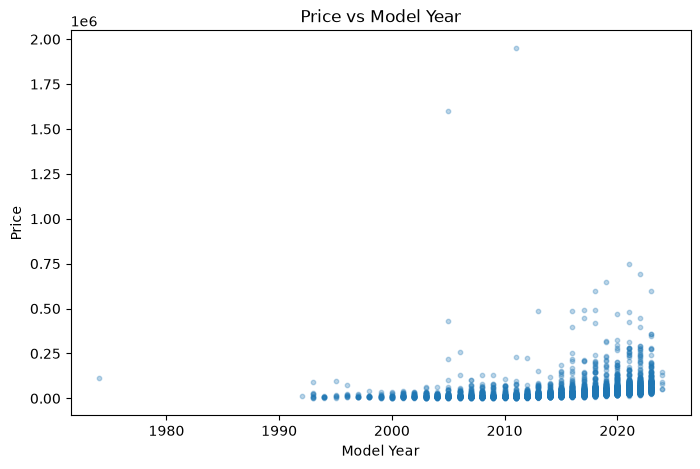

In [29]:
plt.figure(figsize=(8,5))
plt.scatter(df['model_year'], df['price'], alpha=0.3, s=10)
plt.xlabel('Model Year')
plt.ylabel('Price')
plt.title('Price vs Model Year')
plt.show()

<Figure size 800x500 with 0 Axes>

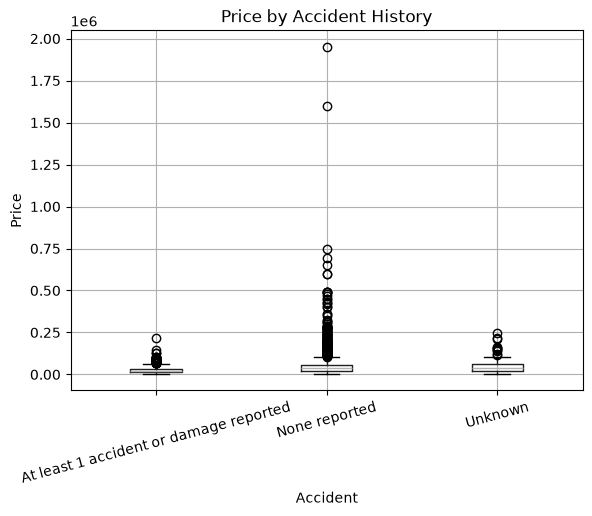

In [30]:
plt.figure(figsize=(8,5))
df.boxplot(column='price', by='accident')
plt.xlabel('Accident')
plt.ylabel('Price')
plt.title('Price by Accident History')
plt.suptitle('')
plt.xticks(rotation=15)
plt.show()

In [31]:
top_brands = df['brand'].value_counts().head(15).index
avg_price_by_brand = df[df['brand'].isin(top_brands)].groupby('brand')['price'].mean().sort_values()

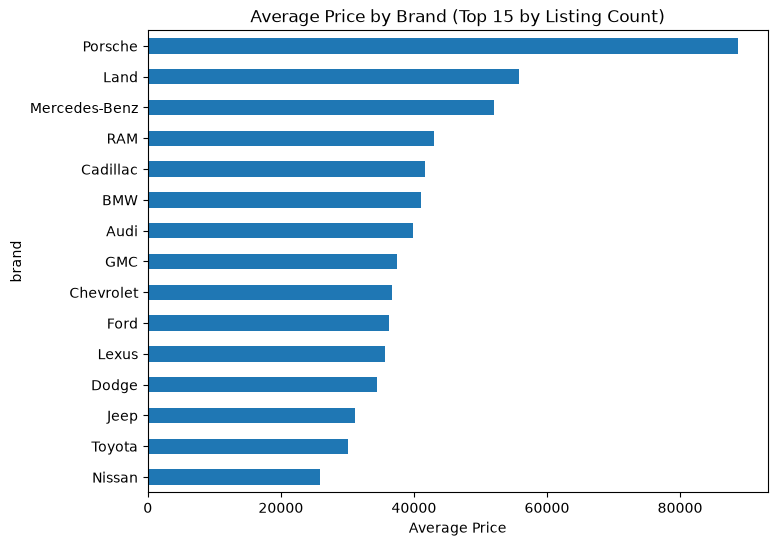

In [32]:
plt.figure(figsize=(8,6))
avg_price_by_brand.plot(kind='barh')
plt.xlabel('Average Price')
plt.title('Average Price by Brand (Top 15 by Listing Count)')
plt.show()

In [33]:
df['brand'].unique()

<ArrowStringArray>
[         'Ford',       'Hyundai',         'Lexus',      'INFINITI',
          'Audi',         'Acura',           'BMW',         'Tesla',
          'Land',         'Aston',        'Toyota',       'Lincoln',
        'Jaguar', 'Mercedes-Benz',         'Dodge',        'Nissan',
       'Genesis',     'Chevrolet',           'Kia',          'Jeep',
       'Bentley',         'Honda',         'Lucid',          'MINI',
       'Porsche',        'Hummer',      'Chrysler',         'Volvo',
      'Cadillac',   'Lamborghini',      'Maserati',    'Volkswagen',
        'Subaru',        'Rivian',           'GMC',           'RAM',
          'Alfa',       'Ferrari',         'Scion',    'Mitsubishi',
         'Mazda',        'Saturn',       'Bugatti',      'Polestar',
   'Rolls-Royce',       'McLaren',         'Buick',         'Lotus',
       'Pontiac',          'FIAT',         'Karma',          'Saab',
       'Mercury',      'Plymouth',         'smart',       'Maybach',
        'Suzuki

In [34]:
df[df['brand'].isin(['Land', 'Aston', 'Alfa'])][['brand', 'model']].head(10)

,brand,model
10,Land,Rover Range Rover Sport 3.0 Supercharged HST
11,Aston,Martin DBS Superleggera
15,Land,Rover LR4 HSE
80,Land,Rover Discovery Sport SE R-Dynamic
93,Aston,Martin DBS Superleggera
110,Land,Rover LR4 HSE LUX Landmark Edition
120,Land,Rover Range Rover Sport 3.0L Supercharged HSE
135,Land,Rover LR3 HSE
148,Land,Rover Range Rover Evoque Pure
151,Alfa,Romeo Stelvio Ti Sport


In [35]:
fixes = {'Land': 'Land Rover', 'Aston': 'Aston Martin', 'Alfa': 'Alfa Romeo'}
strip_words = {'Land': 'Rover', 'Aston': 'Martin', 'Alfa': 'Romeo'}

for old_brand, word in strip_words.items():
    mask = df['brand'] == old_brand
    df.loc[mask, 'model'] = df.loc[mask, 'model'].str.replace(f'^{word} ', '', regex=True)

df['brand'] = df['brand'].replace(fixes)

In [36]:
df[df['brand'].isin(['Land Rover', 'Aston Martin', 'Alfa Romeo'])][['brand', 'model']].head(10)

,brand,model
10,Land Rover,Range Rover Sport 3.0 Supercharged HST
11,Aston Martin,DBS Superleggera
15,Land Rover,LR4 HSE
80,Land Rover,Discovery Sport SE R-Dynamic
93,Aston Martin,DBS Superleggera
110,Land Rover,LR4 HSE LUX Landmark Edition
120,Land Rover,Range Rover Sport 3.0L Supercharged HSE
135,Land Rover,LR3 HSE
148,Land Rover,Range Rover Evoque Pure
151,Alfa Romeo,Stelvio Ti Sport


In [37]:
df['horsepower'] = df['engine'].str.extract(r'(\d+\.?\d*)HP').astype(float)

In [38]:
df['engine_liters'] = df['engine'].str.extract(r'(\d+\.?\d*)L').astype(float)

In [39]:
df['cylinders'] = df['engine'].str.extract(r'(\d+) Cylinder').astype(float)

In [40]:
df[['horsepower', 'engine_liters', 'cylinders']].isnull().sum()

horsepower       808
engine_liters    377
cylinders        945
dtype: int64

In [41]:
df[df['brand'].isin(['Tesla', 'Rivian', 'Lucid', 'Polestar'])][['brand', 'engine', 'horsepower', 'engine_liters', 'cylinders']]

,brand,engine,horsepower,engine_liters,cylinders
9,Tesla,534.0HP Electric Motor Electric Fuel System,534.0,NaN,NaN
44,Lucid,536.0HP Electric Motor Electric Fuel System,536.0,NaN,NaN
68,Lucid,536.0HP Electric Motor Electric Fuel System,536.0,NaN,NaN
92,Rivian,835.0HP Electric Motor Electric Fuel System,835.0,NaN,NaN
122,Rivian,835.0HP Electric Motor Electric Fuel System,835.0,NaN,NaN
...,...,...,...,...,...
3906,Tesla,425.0HP Electric Motor Electric Fuel System,425.0,NaN,NaN
3908,Tesla,Electric,NaN,NaN,NaN
3913,Tesla,518.0HP Electric Motor Electric Fuel System,518.0,NaN,NaN
3932,Tesla,778.0HP Electric Motor Electric Fuel System,778.0,NaN,NaN


In [42]:
df[df['cylinders'].isna()]['engine'].head(20)

1                            3.8L V6 24V GDI DOHC
2                                  3.5 Liter DOHC
4                      2.0L I4 16V GDI DOHC Turbo
5                                       2.4 Liter
9     534.0HP Electric Motor Electric Fuel System
10                                             V6
14                         2.0 Liter Supercharged
16                     2.0L I4 16V GDI DOHC Turbo
22                                3.0 Liter Turbo
23                3.5L V6 24V PDI DOHC Twin Turbo
26                                      1.8 Liter
29       2.0L I4 16V GDI DOHC Turbo Flexible Fuel
32                                         120 AH
36                                3.0 Liter Turbo
41                                 3.5 Liter SOHC
43                      4.4 Liter DOHC Twin Turbo
44    536.0HP Electric Motor Electric Fuel System
46                            5.3L V8 16V GDI OHV
51                           2.4L I4 16V GDI DOHC
56                     1.5L I3 12V GDI DOHC Turbo


In [43]:
df['engine_liters'] = df['engine'].str.extract(r'(\d+\.?\d*)\s?L(?:iter)?').astype(float)

In [45]:
cyl_extract = df['engine'].str.extract(r'[VI](\d+)|(\d+)\s?Cylinder')
df['cylinders'] = cyl_extract[0].fillna(cyl_extract[1]).astype(float)

In [46]:
df[['horsepower', 'engine_liters', 'cylinders']].isnull().sum()

horsepower       808
engine_liters    217
cylinders        440
dtype: int64

In [47]:
df['is_electric'] = df['fuel_type'].isin(['Electric']) | df['engine'].str.contains('Electric', case=False, na=False)
df['is_electric'] = df['is_electric'].astype(int)
df['is_electric'].value_counts()

is_electric
0    3661
1     347
Name: count, dtype: int64

In [48]:
df[df['brand'].isin(['Tesla', 'Rivian', 'Lucid'])]['fuel_type'].value_counts()

fuel_type
Unknown    107
Name: count, dtype: int64

In [49]:
df.loc[df['is_electric'] == 1, 'engine_liters'] = df.loc[df['is_electric'] == 1, 'engine_liters'].fillna(0)
df.loc[df['is_electric'] == 1, 'cylinders'] = df.loc[df['is_electric'] == 1, 'cylinders'].fillna(0)

In [50]:
non_ev_mask = df['is_electric'] == 0
df.loc[non_ev_mask, 'engine_liters'] = df.loc[non_ev_mask, 'engine_liters'].fillna(df.loc[non_ev_mask, 'engine_liters'].median())
df.loc[non_ev_mask, 'cylinders'] = df.loc[non_ev_mask, 'cylinders'].fillna(df.loc[non_ev_mask, 'cylinders'].median())

In [51]:
df['horsepower'] = df['horsepower'].fillna(df.groupby('is_electric')['horsepower'].transform('median'))

In [52]:
df[['horsepower', 'engine_liters', 'cylinders']].isnull().sum()

horsepower       0
engine_liters    0
cylinders        0
dtype: int64

In [53]:
df['transmission'].value_counts()

transmission
A/T                                  1037
8-Speed A/T                           406
Transmission w/Dual Shift Mode        397
6-Speed A/T                           362
6-Speed M/T                           248
                                     ... 
7-Speed DCT Automatic                   1
9-Speed Automatic with Auto-Shift       1
SCHEDULED FOR OR IN PRODUCTION          1
6 Speed Mt                              1
8-Speed Manual                          1
Name: count, Length: 62, dtype: int64

In [54]:
(df == '–').sum()

brand              0
model              0
model_year         0
milage             0
fuel_type          0
engine            45
transmission       4
ext_col           15
int_col          133
accident           0
clean_title        0
price              0
horsepower         0
engine_liters      0
cylinders          0
is_electric        0
dtype: int64

In [55]:
df = df.replace('–', pd.NA)

In [56]:
def simplify_transmission(t):
    if pd.isna(t):
        return 'Unknown'
    t = t.upper()
    if 'CVT' in t:
        return 'CVT'
    if 'M/T' in t or 'MANUAL' in t or t.strip() == 'MT':
        return 'Manual'
    if 'A/T' in t or 'AUTOMATIC' in t or 'AUTO' in t or 'DUAL SHIFT' in t:
        return 'Automatic'
    return 'Unknown'

df['transmission_type'] = df['transmission'].apply(simplify_transmission)

In [57]:
df['transmission_speeds'] = df['transmission'].str.extract(r'(\d+)[\s-]?Speed', flags=1).astype(float)

In [58]:
df['transmission_type'].value_counts()

transmission_type
Automatic    3507
Manual        374
CVT           100
Unknown        27
Name: count, dtype: int64

In [59]:
df['transmission_speeds'].isnull().sum()

np.int64(1852)

In [60]:
df[df['transmission_speeds'].isna()]['transmission'].value_counts().head(15)

transmission
A/T                               1037
Transmission w/Dual Shift Mode     397
Automatic                          237
CVT Transmission                    62
M/T                                 40
Automatic CVT                       37
Transmission Overdrive Switch        7
Variable                             4
Automatic, 8-Spd                     4
2                                    3
F                                    2
Manual                               2
Automatic, 9-Spd 9G-Tronic           2
Manual, 6-Spd                        2
CVT-F                                1
Name: count, dtype: int64

In [61]:
df['transmission_speeds'] = df['transmission'].str.extract(r'(\d+)[\s-]?(?:Speed|Spd)', flags=1).astype(float)

In [62]:
df['transmission_speeds'].isnull().sum()

np.int64(1837)

In [63]:
df['transmission_speeds'] = df['transmission_speeds'].fillna(df.groupby('transmission_type')['transmission_speeds'].transform('median'))

In [64]:
df['transmission_speeds'].isnull().sum()

np.int64(100)

In [65]:
df.loc[df['transmission_type'] == 'CVT', 'transmission_speeds'] = 0

In [66]:
df['transmission_speeds'].isnull().sum()

np.int64(0)

In [67]:
df[['engine', 'ext_col', 'int_col']].isnull().sum()

engine      45
ext_col     15
int_col    133
dtype: int64

In [68]:
df['ext_col'] = df['ext_col'].fillna('Unknown')
df['int_col'] = df['int_col'].fillna('Unknown')

In [69]:
df['model'].value_counts().head(20)

model
M3 Base                  30
F-150 XLT                24
Corvette Base            22
1500 Laramie             18
Model Y Long Range       17
Camaro 2SS               17
Wrangler Sport           17
Mustang GT Premium       16
911 Carrera              16
M4 Base                  15
911 Carrera S            14
Explorer XLT             14
F-250 Lariat             14
M5 Base                  13
E-Class E 350 4MATIC     13
F-150 Lariat             13
E-Class E 350            13
R1S Adventure Package    12
Land Cruiser Base        12
ES 350 Base              12
Name: count, dtype: int64

In [70]:
model_counts = df['model'].value_counts()
model_counts.describe()

count    1898.000000
mean        2.111697
std         2.236695
min         1.000000
25%         1.000000
50%         1.000000
75%         2.000000
max        30.000000
Name: count, dtype: float64

In [71]:
model_counts = df['model'].value_counts()
common_models = model_counts[model_counts >= 5].index
df['model_grouped'] = df['model'].where(df['model'].isin(common_models), 'Other')
df['model_grouped'].nunique()

162

In [72]:
df['model_grouped'].value_counts().head(10)

model_grouped
Other                 2751
M3 Base                 30
F-150 XLT               24
Corvette Base           22
1500 Laramie            18
Model Y Long Range      17
Camaro 2SS              17
Wrangler Sport          17
Mustang GT Premium      16
911 Carrera             16
Name: count, dtype: int64

In [73]:
df.isnull().sum()

brand                   0
model                   0
model_year              0
milage                  0
fuel_type               0
engine                 45
transmission            4
ext_col                 0
int_col                 0
accident                0
clean_title             0
price                   0
horsepower              0
engine_liters           0
cylinders               0
is_electric             0
transmission_type       0
transmission_speeds     0
model_grouped           0
dtype: int64

In [74]:
df.shape

(4008, 19)

In [75]:
df = df.drop(columns=['engine', 'transmission', 'model'])
df.shape

(4008, 16)

In [76]:
df.isnull().sum()

brand                  0
model_year             0
milage                 0
fuel_type              0
ext_col                0
int_col                0
accident               0
clean_title            0
price                  0
horsepower             0
engine_liters          0
cylinders              0
is_electric            0
transmission_type      0
transmission_speeds    0
model_grouped          0
dtype: int64

In [77]:
df.info()

<class 'pandas.DataFrame'>
Index: 4008 entries, 0 to 4008
Data columns (total 16 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   brand                4008 non-null   str    
 1   model_year           4008 non-null   int64  
 2   milage               4008 non-null   int64  
 3   fuel_type            4008 non-null   str    
 4   ext_col              4008 non-null   str    
 5   int_col              4008 non-null   str    
 6   accident             4008 non-null   str    
 7   clean_title          4008 non-null   str    
 8   price                4008 non-null   int64  
 9   horsepower           4008 non-null   float64
 10  engine_liters        4008 non-null   float64
 11  cylinders            4008 non-null   float64
 12  is_electric          4008 non-null   int64  
 13  transmission_type    4008 non-null   str    
 14  transmission_speeds  4008 non-null   float64
 15  model_grouped        4008 non-null   str    
dtypes: f

In [78]:
df['clean_title'].unique()

<ArrowStringArray>
['Yes', 'No']
Length: 2, dtype: str

In [79]:
df['accident'].unique()

<ArrowStringArray>
['At least 1 accident or damage reported', 'None reported', 'Unknown']
Length: 3, dtype: str

In [80]:
df['clean_title'] = df['clean_title'].map({'Yes': 1, 'No': 0})

In [81]:
df['had_accident'] = df['accident'].map({
    'At least 1 accident or damage reported': 1,
    'None reported': 0,
    'Unknown': -1
})

In [82]:
df[['clean_title', 'accident', 'had_accident']].head()

,clean_title,accident,had_accident
0,1,At least 1 accident or damage reported,1
1,1,At least 1 accident or damage reported,1
2,0,None reported,0
3,1,None reported,0
4,0,None reported,0


In [83]:
df = df.drop(columns=['accident'])

In [84]:
for col in ['brand', 'fuel_type', 'ext_col', 'int_col', 'transmission_type', 'model_grouped']:
    print(col, '-', df[col].nunique())

brand - 57
fuel_type - 6
ext_col - 319
int_col - 156
transmission_type - 4
model_grouped - 162


In [85]:
df['ext_col'].value_counts().describe()

count    319.000000
mean      12.564263
std       79.791837
min        1.000000
25%        1.000000
50%        1.000000
75%        2.000000
max      905.000000
Name: count, dtype: float64

In [86]:
df['int_col'].value_counts().describe()

count     156.000000
mean       25.692308
std       172.104980
min         1.000000
25%         1.000000
50%         1.000000
75%         2.000000
max      2025.000000
Name: count, dtype: float64

In [87]:
for col in ['ext_col', 'int_col']:
    counts = df[col].value_counts()
    common = counts[counts >= 5].index
    df[col] = df[col].where(df[col].isin(common), 'Other')

print(df['ext_col'].nunique(), df['int_col'].nunique())

30 23


In [88]:
categorical_cols = ['brand', 'fuel_type', 'ext_col', 'int_col', 'transmission_type', 'model_grouped']
df = pd.get_dummies(df, columns=categorical_cols, drop_first=True)
df.shape

(4008, 286)

In [89]:
df.dtypes.value_counts()

bool       276
int64        6
float64      4
Name: count, dtype: int64

In [90]:
df.select_dtypes(include='object').columns

Index([], dtype='str')

In [91]:
df.info()

<class 'pandas.DataFrame'>
Index: 4008 entries, 0 to 4008
Columns: 286 entries, model_year to model_grouped_i8 Base
dtypes: bool(276), float64(4), int64(6)
memory usage: 1.4 MB


In [92]:
from sklearn.model_selection import train_test_split

In [93]:
X = df.drop(columns=['price'])
y = df['price']

In [94]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [95]:
X_train.shape, X_test.shape

((3206, 285), (802, 285))

In [96]:
from sklearn.preprocessing import StandardScaler

In [97]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [98]:
y_train.describe(), y_test.describe()

(count      3206.000000
 mean      42749.555833
 std       51829.220939
 min        2000.000000
 25%       17000.000000
 50%       30909.500000
 75%       49500.000000
 max      749950.000000
 Name: price, dtype: float64,
 count    8.020000e+02
 mean     4.813539e+04
 std      9.827123e+04
 min      2.300000e+03
 25%      1.790000e+04
 50%      3.205350e+04
 75%      5.099975e+04
 max      1.950995e+06
 Name: price, dtype: float64)

In [99]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

In [100]:
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](285,)","[13489.27,-8475.83, 2915.04,..., 310.96, 424.91, 2306.77]"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,4.275e+04
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,285
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(284)
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](285,)","[118.22,101.65, 94.89,..., 3.9 , 2.23, 0. ]"


In [101]:
rf = RandomForestRegressor(random_state=42)
rf.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease o

In [103]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [104]:
lr_preds = lr.predict(X_test_scaled)
rf_preds = rf.predict(X_test)

In [105]:
def evaluate(y_true, y_pred, name):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = mean_squared_error(y_true, y_pred) ** 0.5
    r2 = r2_score(y_true, y_pred)
    print(name)
    print('MAE: ', round(mae, 2))
    print('RMSE:', round(rmse, 2))
    print('R2:  ', round(r2, 4))
    print()

evaluate(y_test, lr_preds, 'Linear Regression')
evaluate(y_test, rf_preds, 'Random Forest')

Linear Regression
MAE:  18821.97
RMSE: 89878.6
R2:   0.1625

Random Forest
MAE:  12878.24
RMSE: 84910.3
R2:   0.2525



In [106]:
mask = y_test < 200000
evaluate(y_test[mask], rf_preds[mask], 'Random Forest (excluding prices > $200K)')
evaluate(y_test[mask], lr_preds[mask], 'Linear Regression (excluding prices > $200K)')

Random Forest (excluding prices > $200K)
MAE:  7461.57
RMSE: 12469.75
R2:   0.8431

Linear Regression (excluding prices > $200K)
MAE:  13170.63
RMSE: 21444.11
R2:   0.536



In [107]:
y_train_log = np.log1p(y_train)
y_test_log = np.log1p(y_test)

In [109]:
lr_log = LinearRegression()
lr_log.fit(X_train_scaled, y_train_log)



,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](285,)","[ 0.33,-0.31, 0.02,..., 0.01, 0.01, 0.04]"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,10.29
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,285
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(284)
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](285,)","[118.22,101.65, 94.89,..., 3.9 , 2.23, 0. ]"


In [110]:
rf_log = RandomForestRegressor(random_state=42)
rf_log.fit(X_train, y_train_log)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease o

In [111]:
lr_log_preds = np.expm1(lr_log.predict(X_test_scaled))
rf_log_preds = np.expm1(rf_log.predict(X_test))

In [112]:
evaluate(y_test, lr_log_preds, 'Linear Regression (log-transformed target)')
evaluate(y_test, rf_log_preds, 'Random Forest (log-transformed target)')

Linear Regression (log-transformed target)
MAE:  14477.47
RMSE: 89014.52
R2:   0.1785

Random Forest (log-transformed target)
MAE:  13328.44
RMSE: 86168.45
R2:   0.2302



In [113]:
mask = y_test < 200000
evaluate(y_test[mask], rf_log_preds[mask], 'Random Forest log-transformed (excluding prices > $200K)')
evaluate(y_test[mask], lr_log_preds[mask], 'Linear Regression log-transformed (excluding prices > $200K)')

Random Forest log-transformed (excluding prices > $200K)
MAE:  7596.24
RMSE: 13139.05
R2:   0.8258

Linear Regression log-transformed (excluding prices > $200K)
MAE:  8745.4
RMSE: 16131.72
R2:   0.7374



In [114]:
importances = pd.Series(rf.feature_importances_, index=X_train.columns).sort_values(ascending=False)
importances.head(15)

milage                         0.326659
engine_liters                  0.130043
cylinders                      0.111468
brand_Lamborghini              0.086365
horsepower                     0.074333
brand_Rolls-Royce              0.067051
model_year                     0.039299
brand_Porsche                  0.022113
brand_Ferrari                  0.012560
int_col_Other                  0.011845
brand_Bentley                  0.010894
ext_col_Other                  0.009723
model_grouped_Metris Base      0.008837
transmission_speeds            0.007417
model_grouped_AMG G 63 Base    0.006889
dtype: float64

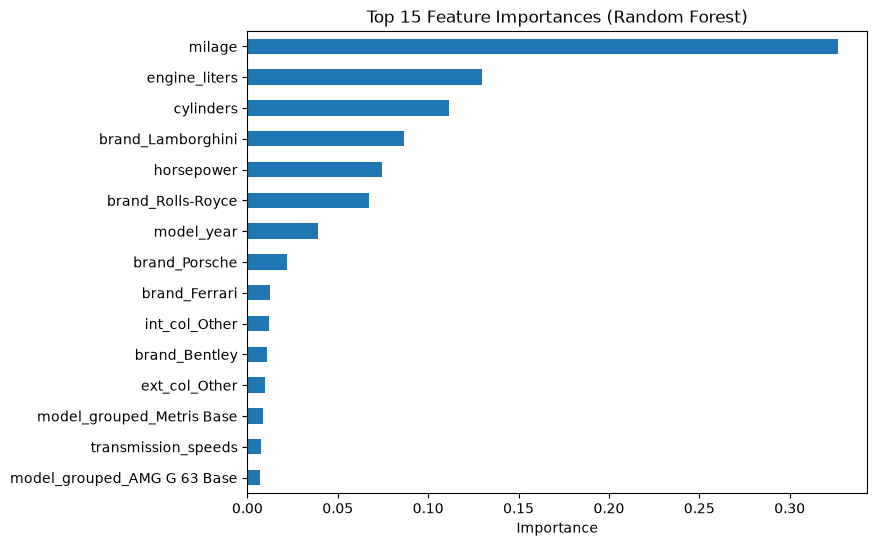

In [115]:
plt.figure(figsize=(8,6))
importances.head(15).plot(kind='barh')
plt.gca().invert_yaxis()
plt.xlabel('Importance')
plt.title('Top 15 Feature Importances (Random Forest)')
plt.show()

In [116]:
from sklearn.model_selection import GridSearchCV

In [117]:
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5, 10],
    'max_features': ['sqrt', 1.0]
}

In [118]:
grid_search = GridSearchCV(
    RandomForestRegressor(random_state=42),
    param_grid,
    cv=5,
    scoring='neg_mean_absolute_error',
    n_jobs=-1
)
grid_search.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestR...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [None, 10, ...], 'max_features': ['sqrt', 1.0], 'min_samples_split': [2, 5, ...], 'n_estimators': [100, 200, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_mean_absolute_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for call

In [119]:
grid_search.best_params_

{'max_depth': None,
 'max_features': 1.0,
 'min_samples_split': 2,
 'n_estimators': 300}

In [120]:
-grid_search.best_score_

np.float64(9916.285956159492)

In [121]:
best_rf = grid_search.best_estimator_
best_rf_preds = best_rf.predict(X_test)
evaluate(y_test, best_rf_preds, 'Random Forest (tuned)')

Random Forest (tuned)
MAE:  12877.04
RMSE: 84414.77
R2:   0.2612



In [122]:
mask = y_test < 200000
evaluate(y_test[mask], best_rf_preds[mask], 'Random Forest tuned (excluding prices > $200K)')

Random Forest tuned (excluding prices > $200K)
MAE:  7532.45
RMSE: 12646.88
R2:   0.8386



In [123]:
import joblib

In [124]:
joblib.dump(rf, 'used_car_price_model.joblib')

['used_car_price_model.joblib']

In [125]:
joblib.dump(scaler, 'used_car_price_scaler.joblib')

['used_car_price_scaler.joblib']

In [126]:
loaded_model = joblib.load('used_car_price_model.joblib')
loaded_model.predict(X_test.head())

array([10650.98, 10696.79, 28113.74, 21728.03, 52041.52])